In [94]:
import sys
from pathlib import Path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import gymnasium as gym
from gymnasium.spaces import Dict, MultiDiscrete, Box
from sb3_contrib import MaskablePPO
from sb3_contrib.common.maskable.callbacks import MaskableEvalCallback
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.env_util import make_vec_env
import numpy as np
from scipy.signal import convolve2d
from typing import Literal
from src.config import (
    LAND_COVER_LABELS, PROTECTED_CLASSES,
    N_CLASSES, N_PIXELS_PER_CELL, SAMPLE_SIZE, GRID_KWARGS, SEED, data_dir, log_dir, model_dir, CENTER
) # ECONOMIC_VALUES
import importlib
from src.utils import minmax_normalize, get_logger
import wandb
from wandb.integration.sb3 import WandbCallback
from datetime import date

logger = get_logger(__name__, log_file=Path(log_dir, f"{date.today():%m%d}-1.log"), stream=False, level="DEBUG")

# ── Mock ET cost per land-cover class (mm / year) ──────────────────────
# Higher values → more water consumption → higher environmental cost
ET_COST = {
    1:  100,   # Water        – minimal (surface evaporation counted elsewhere)
    2:  600,   # Trees        – moderate transpiration
    4:  100,   # Flooded      – similar to open water
    5:  850,   # Crops        – irrigation-heavy
    7:  200,   # Built Area   – low (impervious surface)
    8:  50,    # Bare Ground  – very low
    9:  0,     # Snow/Ice     – negligible
    10: 0,     # Clouds       – N/A
    11: 400,   # Rangeland    – moderate
}
ECONOMIC_VALUES = {
    1:  554,    # Water        – fisheries + ecosystem services
    2:  325,    # Trees/Forest – firewood, carbon, water regulation
    4:  554,    # Flooded/Wetlands – same as water/wetlands valuation
    5:  400,    # Crops        – rainfed maize midpoint ($300-$500)
    7:  2000,   # Built Area   – urban real-estate (constraint: very high)
    8:  25,     # Bare Ground  – minimal value
    9:  0,      # Snow/Ice     – no economic value
    10: 0,      # Clouds       – no economic value (masked)
    11: 75,     # Rangeland    – low-intensity grazing
}

norm_et_cost = minmax_normalize(ET_COST)
norm_eco_values = minmax_normalize(ECONOMIC_VALUES)

# Build dense arrays for vectorised reward computation
ECO_PER_CLASS = np.zeros(N_CLASSES, dtype=np.float32)
ET_PER_CLASS  = np.zeros(N_CLASSES, dtype=np.float32)
for _cls, _val in norm_eco_values.items():
    if _cls < N_CLASSES:
        ECO_PER_CLASS[_cls] = _val
for _cls, _val in norm_et_cost.items():
    if _cls < N_CLASSES:
        ET_PER_CLASS[_cls] = _val

# Modifiable (non-protected) land-cover classes
MODIFIABLE_CLASSES = sorted(set(range(N_CLASSES)) - PROTECTED_CLASSES)
N_MOD = len(MODIFIABLE_CLASSES)

# Sliced value vectors for modifiable classes only (length N_MOD)
ECO_MOD = ECO_PER_CLASS[MODIFIABLE_CLASSES]
ET_MOD  = ET_PER_CLASS[MODIFIABLE_CLASSES]

print(f"All classes       : {list(LAND_COVER_LABELS.items())}")
print(f"Protected classes : {PROTECTED_CLASSES}")
print(f"Modifiable classes: {MODIFIABLE_CLASSES}  (n={N_MOD})")
print(f"Pixels per cell   : {N_PIXELS_PER_CELL}")
print(f"Grid size per ep  : {SAMPLE_SIZE}×{SAMPLE_SIZE}")

All classes       : [(1, 'Water'), (2, 'Trees'), (4, 'Flooded'), (5, 'Crops'), (7, 'Built Area'), (8, 'Bare Ground'), (9, 'Snow/Ice'), (10, 'Clouds'), (11, 'Rangeland')]
Protected classes : frozenset({0, 1, 3, 4, 6, 9, 10})
Modifiable classes: [2, 5, 7, 8, 11]  (n=5)
Pixels per cell   : 25
Grid size per ep  : 10×10


In [7]:
ECO_MOD

array([0.1625, 0.2   , 1.    , 0.0125, 0.0375], dtype=float32)

In [8]:
ET_MOD

array([0.7059, 1.    , 0.2353, 0.0588, 0.4706], dtype=float32)

In [9]:
MOD_CLS_TO_IDX = {cls: i for i, cls in enumerate(MODIFIABLE_CLASSES)}

In [10]:
logger.info('Test')

## Env Setup Demo

In [11]:
def augment_data(data, size, seed, split='train_indices', n_augment=10):
    if split == 'no_split':
        indices = np.concatenate((data['train_indices'], data['test_indices']), axis=0)
    else:
        indices = data[split]

    samples = np.stack([
        data['pixel_counts'][i[0]:i[0]+size, i[1]:i[1]+size]
        for i in indices
    ])
    rng = np.random.default_rng(seed)

    if n_augment > 0:
        j = 0
        while j < n_augment:
            augmented = []
            for i in indices:
                sample = data['pixel_counts'][i[0]:i[0]+size, i[1]:i[1]+size]
                flat = sample.reshape(-1, N_CLASSES)
                rng.shuffle(flat)
                augmented.append(flat.reshape(size, size, N_CLASSES))

            samples = np.concatenate([samples, np.stack(augmented)]) 
            j += 1
    return samples

In [12]:
data = np.load(Path(data_dir, "processed", "rl_dataset.npz"))
samples = augment_data(data, 10, SEED, split='no_split')
samples.shape

(275, 10, 10, 12)

In [13]:
samples[0, 0, 0, :]

array([ 0,  5,  0,  0,  0, 18,  0,  0,  1,  0,  0,  1], dtype=int32)

In [14]:
data = np.load(Path(data_dir, "processed", "rl_dataset.npz"))
samples = augment_data(data, 10, SEED, split='train_indices')
samples.shape

(187, 10, 10, 12)

In [79]:
from posixpath import split


class LandUseEnv(gym.Env):
    """
    RL Environment for land-use allocation optimization.

    State: A square grid where each cell has fractions of MODIFIABLE land-cover types (normalized to [0,1])
    Action: Flattened action containing cell coordinates and delta changes for MODIFIABLE classes only
    Reward: Change in total value with spatial modifiers and ET penalty
    """
    metadata = {"render_modes": []}

    def __init__(self, size=10, max_steps=500, delta_boundary=1,
                 split: Literal['train_indices', 'test_indices', 'no_split'] = 'train_indices',
                 add_spatial_reward=True, lambda_cont=0.5, lambda_buf=2.0,
                 lambda_et=1.0, reward_scale=1.0, n_augment=10, et_dcs_tolerance=0.1, min_mod_frac=0.1):
        super().__init__()
        self.size = size
        self.max_steps = max_steps
        self.delta_boundary = delta_boundary
        self.lambda_et = lambda_et
        self.reward_scale = reward_scale
        self.data = np.load(Path(data_dir, "processed", "rl_dataset.npz"))
        self.split = split
        self.initial_total_et  = 0.0
        self.add_spatial_reward = add_spatial_reward
        self.lambda_cont = lambda_cont
        self.lambda_buf = lambda_buf
        self.n_augment = n_augment
        self.et_dcs_tolerance = et_dcs_tolerance
        self.min_mod_frac = min_mod_frac

        # Lookup: modifiable class index → position in MODIFIABLE_CLASSES list
        self._mod_idx = {cls: i for i, cls in enumerate(MODIFIABLE_CLASSES)}

        self.observation_space = Box(
            low=0.0, 
            high=1.0,
            shape=(size, size, N_MOD),
            dtype=np.float32
        )

        delta_choices = 2 * delta_boundary + 1
        self.action_space = MultiDiscrete([size, size] + [delta_choices] * N_MOD)
        
        self.state = None
        self.step_count = 0
        self.prev_total_value = 0.0

    def action_masks(self) -> np.ndarray:
        """
        Return per-dimension masks for MaskablePPO (MultiDiscrete).
        
        Row/col dims: always all valid.
        Delta dims: for each modifiable class k, check across ALL cells whether
        delta=-1 or delta=+1 is feasible for at least one cell. This is a
        conservative global mask — cell-specific enforcement stays in _apply_action.
        """
        masks = [
            np.ones(self.size, dtype=bool),  # row: all valid
            np.ones(self.size, dtype=bool),  # col: all valid
        ]
        # state is in fraction space [0, 1]; convert to pixel quantities for integer checks
        for k in range(N_MOD):
            quantities = self.state[:, :, k] * N_PIXELS_PER_CELL  # (size, size)
            delta_mask = np.ones(2 * self.delta_boundary + 1, dtype=bool)
            for d in range(-self.delta_boundary, self.delta_boundary + 1):
                idx = d + self.delta_boundary  # map to [0, delta_choices)
                if d < 0 and not np.any(quantities >= abs(d)):
                    delta_mask[idx] = False  # no cell can decrease this class
                elif d > 0 and not np.any(quantities <= N_PIXELS_PER_CELL - d):
                    delta_mask[idx] = False  # no cell can increase this class
            masks.append(delta_mask)
        return np.concatenate(masks)
        
    def _decode_action(self, action):
        cell_coords = action[:2]
        mod_deltas = action[2:] - self.delta_boundary  # shape (N_MOD,)
        return cell_coords, mod_deltas
        
    def _compute_total_value(self):
        """
        State is (size, size, N_MOD) fractions for modifiable classes.
        ECO_MOD and ET_MOD are (N_MOD,) value vectors.
        """
        net_values = self.state * (ECO_MOD + ET_MOD)  # (size, size, N_MOD)
        if self.add_spatial_reward:
            spatial_reward, contiguity_bonus, buffer_penalty = self._compute_spatial_modifiers()
        else:
            spatial_reward = contiguity_bonus = buffer_penalty = 0
        total_values = float(net_values.sum()) + spatial_reward
        return total_values, spatial_reward, contiguity_bonus, buffer_penalty
        
    def _compute_total_et(self) -> float:
        """ET using modifiable-only slices."""
        return float((self.state.reshape(-1, N_MOD) @ ET_MOD).sum())

    def _compute_spatial_modifiers(self):
        """
        State is (size, size, N_MOD) fractions.
        Trees=2, Crops=5, Built=7 are modifiable; Water=1, Flooded=4 are protected.
        """
        fractions = self.state
        
        kernel = np.array([[0, 1, 0],
                           [1, 0, 1],
                           [0, 1, 0]])
        
        # Trees is modifiable class 2 → index in N_MOD
        trees = fractions[:, :, self._mod_idx[2]]
        tree_neighbors = convolve2d(trees, kernel, mode='same', boundary='fill', fillvalue=0)
        contiguity_bonus = np.sum(trees * tree_neighbors)
        
        # Water(1) and Flooded(4) are protected — use saved fractions from reset
        water_bodies = self._protected_water
        high_impact = fractions[:, :, self._mod_idx[5]] + fractions[:, :, self._mod_idx[7]]
        water_neighbors = convolve2d(water_bodies, kernel, mode='same', boundary='fill', fillvalue=0)
        buffer_penalty = np.sum(high_impact * water_neighbors)
        
        spatial_reward = (self.lambda_cont * contiguity_bonus) - (self.lambda_buf * buffer_penalty)
        return float(spatial_reward), contiguity_bonus, buffer_penalty

    def _get_obs(self, idx) -> np.ndarray:
        """
        Extract modifiable classes only from the full N_CLASSES pixel counts.
        Returns fractions in [0, 1] with shape (size, size, N_MOD).
        """
        raw = self.samples[idx]  # (size, size, N_CLASSES)
        mod_counts = raw[:, :, MODIFIABLE_CLASSES]  # (size, size, N_MOD)
        self.state = mod_counts.astype(np.float32) / N_PIXELS_PER_CELL

        # Cache protected water fractions for spatial reward (constant during episode)
        self._protected_water = (raw[:, :, 1] + raw[:, :, 4]).astype(np.float32) / N_PIXELS_PER_CELL
        return self.state

    def _apply_action(self, action):
        """
        Apply action with zero-sum constraint on modifiable classes only.
        Clamps deltas to each class's available headroom before applying,
        then re-balances to maintain zero-sum.
        """
        cell_coords, mod_deltas = self._decode_action(action)
        r, c = cell_coords[0], cell_coords[1]
        cur = self.state[r, c, :]

        # skip if all modifiable classes are zero in this cell
        if not cur.any():
            logger.debug(f"Action at cell ({r},{c}) has no modifiable classes, skipping action")
            return self.state

        pos_mask = mod_deltas > 0
        neg_mask = mod_deltas < 0
        pos_sum = np.sum(mod_deltas[pos_mask])
        neg_sum = np.abs(np.sum(mod_deltas[neg_mask]))
        
        if pos_sum == 0 or neg_sum == 0:
            logger.debug(f"Action at cell ({r},{c}) has no positive or negative deltas, skipping action")
            return self.state
        
        # zero-sum: scale so positive and negative changes balance
        target_sum = min(pos_sum, neg_sum)
        final_deltas = np.zeros(N_MOD, dtype=np.float32)
        final_deltas[pos_mask] = mod_deltas[pos_mask] * (target_sum / pos_sum)
        final_deltas[neg_mask] = mod_deltas[neg_mask] * (target_sum / neg_sum)
        
        # convert pixel delta to fraction delta, then clamp to valid range
        fraction_delta = final_deltas / N_PIXELS_PER_CELL
        fraction_delta = np.clip(fraction_delta, -cur, 1.0 - cur)
        
        # re-enforce zero-sum after clamping: scale the larger side down
        clamped_pos = fraction_delta[fraction_delta > 0].sum()
        clamped_neg = np.abs(fraction_delta[fraction_delta < 0].sum())
        
        if clamped_pos == 0 or clamped_neg == 0:
            logger.debug(f"After clamping, action at cell ({r},{c}) has no positive or negative deltas, skipping action")
            return self.state
        
        balance = min(clamped_pos, clamped_neg)
        fraction_delta[fraction_delta > 0] *= balance / clamped_pos
        fraction_delta[fraction_delta < 0] *= balance / clamped_neg
        logger.debug(f"Applying action at cell ({r}, {c}): mod_deltas={mod_deltas}, fraction_delta={fraction_delta}")
        
        logger.debug(f"Original state for cell ({r}, {c}): {self.state[r, c, :]}")
        self.state[r, c, :] = cur + fraction_delta
        logger.debug(f"Updated state for cell ({r}, {c}): {self.state[r, c, :]}")
        return self.state

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.samples = augment_data(self.data, size=self.size, seed=seed, split=self.split, n_augment=self.n_augment)
        
        # resample until we get a patch with enough modifiable classes for more efficient training
        n_cells = self.size * self.size
        for _ in range(100):
            idx = self.np_random.integers(self.samples.shape[0] - 1)
            self.state = self._get_obs(idx).copy()
            mod_frac = np.count_nonzero(self.state.sum(axis=2)) / n_cells
            if mod_frac >= self.min_mod_frac:
                break
        
        self.step_count = 0
        self.prev_total_value, _, _, _ = self._compute_total_value()
        self.initial_total_et = self._compute_total_et()
        info = {"total_value": self.prev_total_value, "et_decrease": 0.0, "step": self.step_count}
        logger.info(f'reset env: mod_frac={mod_frac:.2f}, {info}')
        return self.state, info

    def step(self, action):
        logger.info(f'start step: step_count={self.step_count}, action={action}')
        self._apply_action(action)
        cur_total_value, spatial_reward, contiguity_bonus, buffer_penalty = self._compute_total_value()

        reward = cur_total_value - self.prev_total_value
        self.prev_total_value = cur_total_value
        self.step_count += 1

        # et_decrease > 0 means ET went down (good), < 0 means ET went up
        et_decrease = (self.initial_total_et - self._compute_total_et()) / (self.initial_total_et + 1e-9)
        et_penalty = self.lambda_et * max(0.0, et_decrease)
        # reward -= et_penalty

        reward /= self.reward_scale

        termination_condition = self.step_count >= self.max_steps or et_decrease >= self.et_dcs_tolerance
        if termination_condition:
            logger.info(f"Episode terminating: step_count={self.step_count}, et_decrease={et_decrease:.4f} (tolerance={self.et_dcs_tolerance})")
        terminated = termination_condition
        truncated = False
        info = {
            "total_value": cur_total_value,
            "et_decrease": et_decrease,
            "et_penalty": et_penalty,
            "step": self.step_count,
            "contiguity_bonus": contiguity_bonus,
            "buffer_penalty": buffer_penalty,
            "spatial_reward": spatial_reward,
        }
        logger.info(f'info: {info}')
        return self.state, reward, terminated, truncated, info

In [80]:
delta_boundary = 1
delta_choices = 2 * delta_boundary + 1
action_space = MultiDiscrete([10, 10] + [delta_choices] * N_MOD)
action_space.sample()

array([8, 0, 0, 1, 0, 0, 0])

In [81]:
import torch
import torch.nn as nn
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

class GridCNN(BaseFeaturesExtractor):
    """
    Custom CNN feature extractor for training sample, e.g. 10x10xN_MOD grid observations.
    
    Uses small 3x3 kernels designed for the grid, preserving spatial adjacency that the contiguity
    and buffer reward terms depend on.
    
    Architecture:
        Conv1: N_MOD ch → conv1_features_out channel, 3x3, pad=1, stride=1 -> 10*10*32
        Conv2: conv1_features_out ch → conv2_features_out ch, 3x3, pad=1, stride=2 -> 5*5*64
        FC → features_out
    """
    def __init__(self, observation_space, conv1_features_out=32, conv2_features_out=64, features_out=128):
        super().__init__(observation_space, features_out)
        self.conv1_features_out = conv1_features_out
        self.conv2_features_out = conv2_features_out
        n_channels = observation_space.shape[-1]  # N_MOD
        
        self.cnn = nn.Sequential(
            nn.Conv2d(n_channels, self.conv1_features_out, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(self.conv1_features_out, self.conv2_features_out, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
        )

        with torch.no_grad():
            dummy_input = torch.zeros(1, n_channels, observation_space.shape[0], observation_space.shape[1])
            n_flatten = self.cnn(dummy_input).shape[1]

        self.linear = nn.Sequential(
            nn.Linear(n_flatten, features_out),
            nn.ReLU(),
        )
    
    def forward(self, observations):
        # SB3 provides (batch, H, W, C); PyTorch Conv2d needs (batch, C, H, W)
        x = observations.permute(0, 3, 1, 2).float()
        return self.linear(self.cnn(x))

# Quick shape sanity check
_dummy_obs = torch.randn(1, 10, 10, N_MOD)
_extractor = GridCNN(Box(low=0.0, high=1.0, shape=(10, 10, N_MOD), dtype=np.float32), features_out=128)
_out = _extractor(_dummy_obs)
print(f"GridCNN: input {tuple(_dummy_obs.shape)} → output {tuple(_out.shape)}")
del _dummy_obs, _extractor, _out

GridCNN: input (1, 10, 10, 5) → output (1, 128)


In [82]:
from stable_baselines3.common.callbacks import BaseCallback
import numpy as np

# Log metrics in WandB cloud
class SpatialMetricsCallback(BaseCallback):
    """
    Custom callback for logging spatial environment metrics from the info dict.
    """
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.contiguity_buffer = []
        self.penalty_buffer = []
        self.et_decrease_buffer = []

    def _on_step(self) -> bool:
        # extract the info dict from the current step
        # self.locals["infos"] is a list because SB3 vectorizes environments
        for info in self.locals.get("infos", []):
            if "contiguity_bonus" in info:
                self.contiguity_buffer.append(info["contiguity_bonus"])
            if "buffer_penalty" in info:
                self.penalty_buffer.append(info["buffer_penalty"])
            if "et_decrease" in info:
                self.et_decrease_buffer.append(info["et_decrease"])
        return True
        
    def _on_rollout_end(self) -> None:
        # log the mean of the metrics at the end of every rollout
        if self.contiguity_buffer:
            self.logger.record("spatial/contiguity_bonus_mean", np.mean(self.contiguity_buffer))
            self.contiguity_buffer = []
            
        if self.penalty_buffer:
            self.logger.record("spatial/buffer_penalty_mean", np.mean(self.penalty_buffer))
            self.penalty_buffer = []
        
        if self.et_decrease_buffer:
            self.logger.record("spatial/et_decrease_mean", np.mean(self.et_decrease_buffer))
            self.et_decrease_buffer = []

In [83]:
config = {
    "policy_type": "MlpPolicy",  
    "features_extractor": "GridCNN",
    "features_out": 128,
    "env_name": "LakeMalawiLandUse-v0",
    "total_timesteps": 500_000, # 500_000,
    "n_steps": 2048,
    "batch_size": 128,         
    "n_epochs": 10, 
    "learning_rate": 3e-4,
    "gamma": 0.99,
    "gae_lambda": 0.95,
    "clip_range": 0.2,
    "ent_coef": 0.02,              
    "vf_coef": 0.5,
    "max_grad_norm": 0.5,
    "max_steps": 500, # 500
    "lambda_cont": 0.5,
    "lambda_buf": 0.5,         
    "lambda_et": 1.0,
    "reward_scale": 1.0,
    "n_augment": 0,     
    "et_dcs_tolerance": 1,
}

# set customized arch for Actor-Critic net
policy_kwargs = dict(
    features_extractor_class=GridCNN,  # use customized extractor instead of the default flatten layer
    features_extractor_kwargs=dict(features_out=config["features_out"]),
    # # no MLP layers - CNN output goes straight to action/value heads, e.g. Linear(features_out → action_dim/value_dim)
    # net_arch=[]
    share_features_extractor=True,
)

In [84]:
# initialize WandB
run = wandb.init(
    project="CS8903-odc",
    config=config,
    sync_tensorboard=True,
    save_code=True,
)

logger.info("Creating environment …")
env = LandUseEnv(
    split="train_indices",
    max_steps=config["max_steps"],
    lambda_cont=config["lambda_cont"],
    lambda_buf=config["lambda_buf"],
    lambda_et=config["lambda_et"],
    reward_scale=config["reward_scale"],
    n_augment=config["n_augment"],
    et_dcs_tolerance=config["et_dcs_tolerance"],
)

# num_envs = 4
# env = make_vec_env(
#     LandUseEnv,
#     n_envs=num_envs,
#     env_kwargs=dict(
#         split="train_indices",
#         max_steps=config["max_steps"],
#         lambda_cont=config["lambda_cont"],
#         lambda_buf=config["lambda_buf"],
#         lambda_et=config["lambda_et"],
#         reward_scale=config["reward_scale"],
#     ),
# )
# print(env.num_envs)

In [85]:
model = MaskablePPO(
    config["policy_type"],
    env,
    verbose=1,
    policy_kwargs=policy_kwargs,
    learning_rate=config["learning_rate"],
    n_steps=config["n_steps"],
    batch_size=config["batch_size"],
    n_epochs=config["n_epochs"],
    gamma=config["gamma"],
    gae_lambda=config["gae_lambda"],
    clip_range=config["clip_range"],
    ent_coef=config["ent_coef"],
    vf_coef=config["vf_coef"],
    max_grad_norm=config["max_grad_norm"],
    tensorboard_log=f"runs/{run.id}",
)

# print model architecture
print(model.policy)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
MaskableActorCriticPolicy(
  (features_extractor): GridCNN(
    (cnn): Sequential(
      (0): Conv2d(5, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Flatten(start_dim=1, end_dim=-1)
    )
    (linear): Sequential(
      (0): Linear(in_features=1600, out_features=128, bias=True)
      (1): ReLU()
    )
  )
  (pi_features_extractor): GridCNN(
    (cnn): Sequential(
      (0): Conv2d(5, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Flatten(start_dim=1, end_dim=-1)
    )
    (linear): Sequential(
      (0): Linear(in_features=1600, out_features=128, bias=True)
      (1): ReLU()
    )
  )
  (vf_features_extractor): GridCNN(
    (cnn): S

In [86]:
# combine callbacks
callbacks = [
    SpatialMetricsCallback(),
    WandbCallback(
        gradient_save_freq=100,
        model_save_path=f"models/{run.id}",
        verbose=2,
    ),
]

# train the agent
model.learn(total_timesteps=config["total_timesteps"], callback=callbacks)
run.finish()

wandb: WARNING When using several event log directories, please call `wandb.tensorboard.patch(root_logdir="...")` before `wandb.init`


Logging to runs/hnt5fcqr/MaskablePPO_1
---------------------------------------
| rollout/                 |          |
|    ep_len_mean           | 500      |
|    ep_rew_mean           | 0.0133   |
| spatial/                 |          |
|    buffer_penalty_mean   | 7.77     |
|    contiguity_bonus_mean | 0.196    |
|    et_decrease_mean      | 0.00348  |
| time/                    |          |
|    fps                   | 1216     |
|    iterations            | 1        |
|    time_elapsed          | 1        |
|    total_timesteps       | 2048     |
---------------------------------------
-----------------------------------------
| rollout/                 |            |
|    ep_len_mean           | 500        |
|    ep_rew_mean           | 0.288      |
| spatial/                 |            |
|    buffer_penalty_mean   | 0.117      |
|    contiguity_bonus_mean | 0.879      |
|    et_decrease_mean      | 0.00494    |
| time/                    |            |
|    fps               

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


global_step,▁▁▁▁▁▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇████
rollout/ep_len_mean,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
rollout/ep_rew_mean,▁▁▁▂▂▃▅▅▅▅▆▇▆▆▆▇▇▇▇▇▇█████▇█▇▇▇▇▇▇▇▇▇▇▇▇
spatial/buffer_penalty_mean,▇▃▄▃▅▆▄█▄▃█▆▅▂▇▄▄▃▅▂▅▄▆▆▂▆▃▆▁▄▄▅▂▅▂▃▃▆██
spatial/contiguity_bonus_mean,▄▁▄▂▃▁▅▂▁▁▁▁▂▃▂▄▁▅▃▃▂▅▃▂▄▂▁▄▇▂▄▄▁▆▅█▅▄▄▂
spatial/et_decrease_mean,██▇▇▅▆▆▅▅▅▃▅▃▄▅▄▅▄▄▆▇▆▄▃▄▄▆▃▃▅▁▅▂▆▆▅▂▄▃▅
time/fps,█▇▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▁▁▂▂▂▂▂▂▂▂▂
train/approx_kl,▂▁▁▁▁▂▁▂▁▁▁▁▂▂▂▁▄▁▂▂▁▂▂▁▁▂█▂▂▂▁▃▂▂▂▃▂▂▂▂
train/clip_fraction,▂▁▂▂▅█▃▄▁▂▆▇▂▆▃▃▂▃▄▃▄▂▆▅▃█▃▅▇▁▄▅▅▄▆▅▅▄█▅
train/clip_range,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+6,...


In [95]:
# Test samples performance

# model_dir = "/Users/yingyao/Desktop/Code.nosync/cs8903/CS8903-odc/notebook/wandb/run"
# best_model_nm = "nfa2e0nt"

# api = wandb.Api()
# run = api.run(f"shakewin/CS8903-odc/runs/{best_model_nm}")  # replace with actual run ID
# run.file("model.zip").download(replace=True)
# model = MaskablePPO.load("model.zip", env=env)

final_obs = {}
env = LandUseEnv(
    split="test_indices",
    max_steps=config['max_steps'],
    lambda_cont=config["lambda_cont"],
    lambda_buf=config["lambda_buf"],
    lambda_et=config["lambda_et"],
    reward_scale=config["reward_scale"],
    n_augment=0,
    et_dcs_tolerance=config["et_dcs_tolerance"],
)

for ep in range(8):
    # override state with specific index instead of random
    _, _ = env.reset()
    obs = env._get_obs(ep).copy()
    env.prev_total_value, _, _, _ = env._compute_total_value()
    env.initial_total_et = env._compute_total_et()
    
    total_reward, done = 0.0, False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        done = terminated or truncated
    coord_idx = data['test_indices'][ep]
    final_obs[tuple(coord_idx)] = obs
    print(f"Episode {ep + 1} (coord_idx={coord_idx}): reward={total_reward:.4f}, steps={info['step']}")

Episode 1 (coord_idx=[40 10]): reward=0.7095, steps=500
Episode 2 (coord_idx=[30 30]): reward=0.0000, steps=500
Episode 3 (coord_idx=[40 40]): reward=0.0000, steps=500
Episode 4 (coord_idx=[10 20]): reward=0.8188, steps=500
Episode 5 (coord_idx=[20  0]): reward=0.6528, steps=500
Episode 6 (coord_idx=[20 40]): reward=0.0000, steps=500
Episode 7 (coord_idx=[30 40]): reward=0.0000, steps=500
Episode 8 (coord_idx=[10 10]): reward=0.0000, steps=500


In [96]:
# Train samples performance

env = LandUseEnv(
    split="train_indices",
    max_steps=config['max_steps'],
    lambda_cont=config["lambda_cont"],
    lambda_buf=config["lambda_buf"],
    lambda_et=config["lambda_et"],
    reward_scale=config["reward_scale"],
    n_augment=0,
    et_dcs_tolerance=config["et_dcs_tolerance"],
)

for ep in range(17):
    # override state with specific index instead of random
    _, _ = env.reset()
    obs = env._get_obs(ep).copy()
    env.prev_total_value, _, _, _ = env._compute_total_value()
    env.initial_total_et = env._compute_total_et()
    
    total_reward, done = 0.0, False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        done = terminated or truncated
    coord_idx = data['train_indices'][ep]
    final_obs[tuple(coord_idx)] = obs
    print(f"Episode {ep + 1} (coord_idx={coord_idx}): reward={total_reward:.4f}, steps={info['step']}")

Episode 1 (coord_idx=[10 30]): reward=-0.0707, steps=500
Episode 2 (coord_idx=[30 10]): reward=0.1987, steps=500
Episode 3 (coord_idx=[0 0]): reward=0.7095, steps=500
Episode 4 (coord_idx=[40 30]): reward=0.0000, steps=500
Episode 5 (coord_idx=[20 10]): reward=0.7095, steps=500
Episode 6 (coord_idx=[10 40]): reward=0.0000, steps=500
Episode 7 (coord_idx=[20 30]): reward=0.0000, steps=500
Episode 8 (coord_idx=[ 0 10]): reward=0.3406, steps=500
Episode 9 (coord_idx=[40 20]): reward=0.4308, steps=500
Episode 10 (coord_idx=[10  0]): reward=0.9082, steps=500
Episode 11 (coord_idx=[ 0 20]): reward=0.4086, steps=500
Episode 12 (coord_idx=[20 20]): reward=0.5931, steps=500
Episode 13 (coord_idx=[30  0]): reward=0.7095, steps=500
Episode 14 (coord_idx=[ 0 30]): reward=0.4529, steps=500
Episode 15 (coord_idx=[ 0 40]): reward=0.0000, steps=500
Episode 16 (coord_idx=[40  0]): reward=0.3690, steps=500
Episode 17 (coord_idx=[30 20]): reward=0.0000, steps=500


In [89]:
# reconstruct the map using model result
# Start from original pixel_counts as fractions so protected classes are preserved
initial_obs = data['pixel_counts'].astype(np.float32) / N_PIXELS_PER_CELL
final_obs_recst = initial_obs.copy()

# Overwrite only modifiable classes with model output (fractions)
for (r, c), obs in final_obs.items():
    for k, cls in enumerate(MODIFIABLE_CLASSES):
        final_obs_recst[r:r+10, c:c+10, cls] = obs[:, :, k]

In [90]:
# Find positions where initial and final differ
diff_mask = ~np.isclose(initial_obs, final_obs_recst, atol=1e-6)
diff_positions = np.argwhere(diff_mask)

# Build list with deltas and sort by abs(delta) descending
diffs = []
for pos in diff_positions:
    r, c, cls = pos
    delta = final_obs_recst[r, c, cls] - initial_obs[r, c, cls]
    diffs.append((r, c, cls, initial_obs[r, c, cls], final_obs_recst[r, c, cls], delta))

diffs.sort(key=lambda x: abs(x[5]), reverse=True)

print(f"Total differing entries: {len(diffs)}")
print(f"Unique (row, col) cells: {len(set((r, c) for r, c, *_ in diffs))}")
print(f"\n{'row':>3s} {'col':>3s} {'cls':>3s}  {'initial':>8s}  {'final':>8s}  {'delta':>8s}")
print("-" * 42)
for r, c, cls, init_val, final_val, delta in diffs:
    print(f"{r:3d} {c:3d} {cls:3d}  {init_val:8.4f}  {final_val:8.4f}  {delta:+8.4f}")


Total differing entries: 58
Unique (row, col) cells: 18

row col cls   initial     final     delta
------------------------------------------
  7   9  11    1.0000    0.0000   -1.0000
 16  28  11    1.0000    0.0000   -1.0000
 18   1  11    1.0000    0.0000   -1.0000
 23  20  11    1.0000    0.0000   -1.0000
 27  19  11    1.0000    0.0000   -1.0000
 38   4  11    1.0000    0.0000   -1.0000
 48  13  11    1.0000    0.0000   -1.0000
 21   1  11    0.9200    0.0000   -0.9200
  6  26  11    0.8400    0.0000   -0.8400
  0  30  11    0.8000    0.0000   -0.8000
 11  31   2    0.0000    0.7200   +0.7200
 43  20  11    0.6400    0.0000   -0.6400
 11  31   5    0.5600    0.0000   -0.5600
 48   3  11    0.5200    0.0000   -0.5200
 16  28   5    0.0000    0.5000   +0.5000
 16  28   7    0.0000    0.5000   +0.5000
  7   9   5    0.0000    0.5000   +0.5000
  7   9   7    0.0000    0.5000   +0.5000
 18   1   5    0.0000    0.5000   +0.5000
 18   1   7    0.0000    0.5000   +0.5000
 27  19   5    0.0

In [91]:
final_obs_recst[39, 0, :]


array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.], dtype=float32)

In [92]:
initial_obs[39, 0, :]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.], dtype=float32)

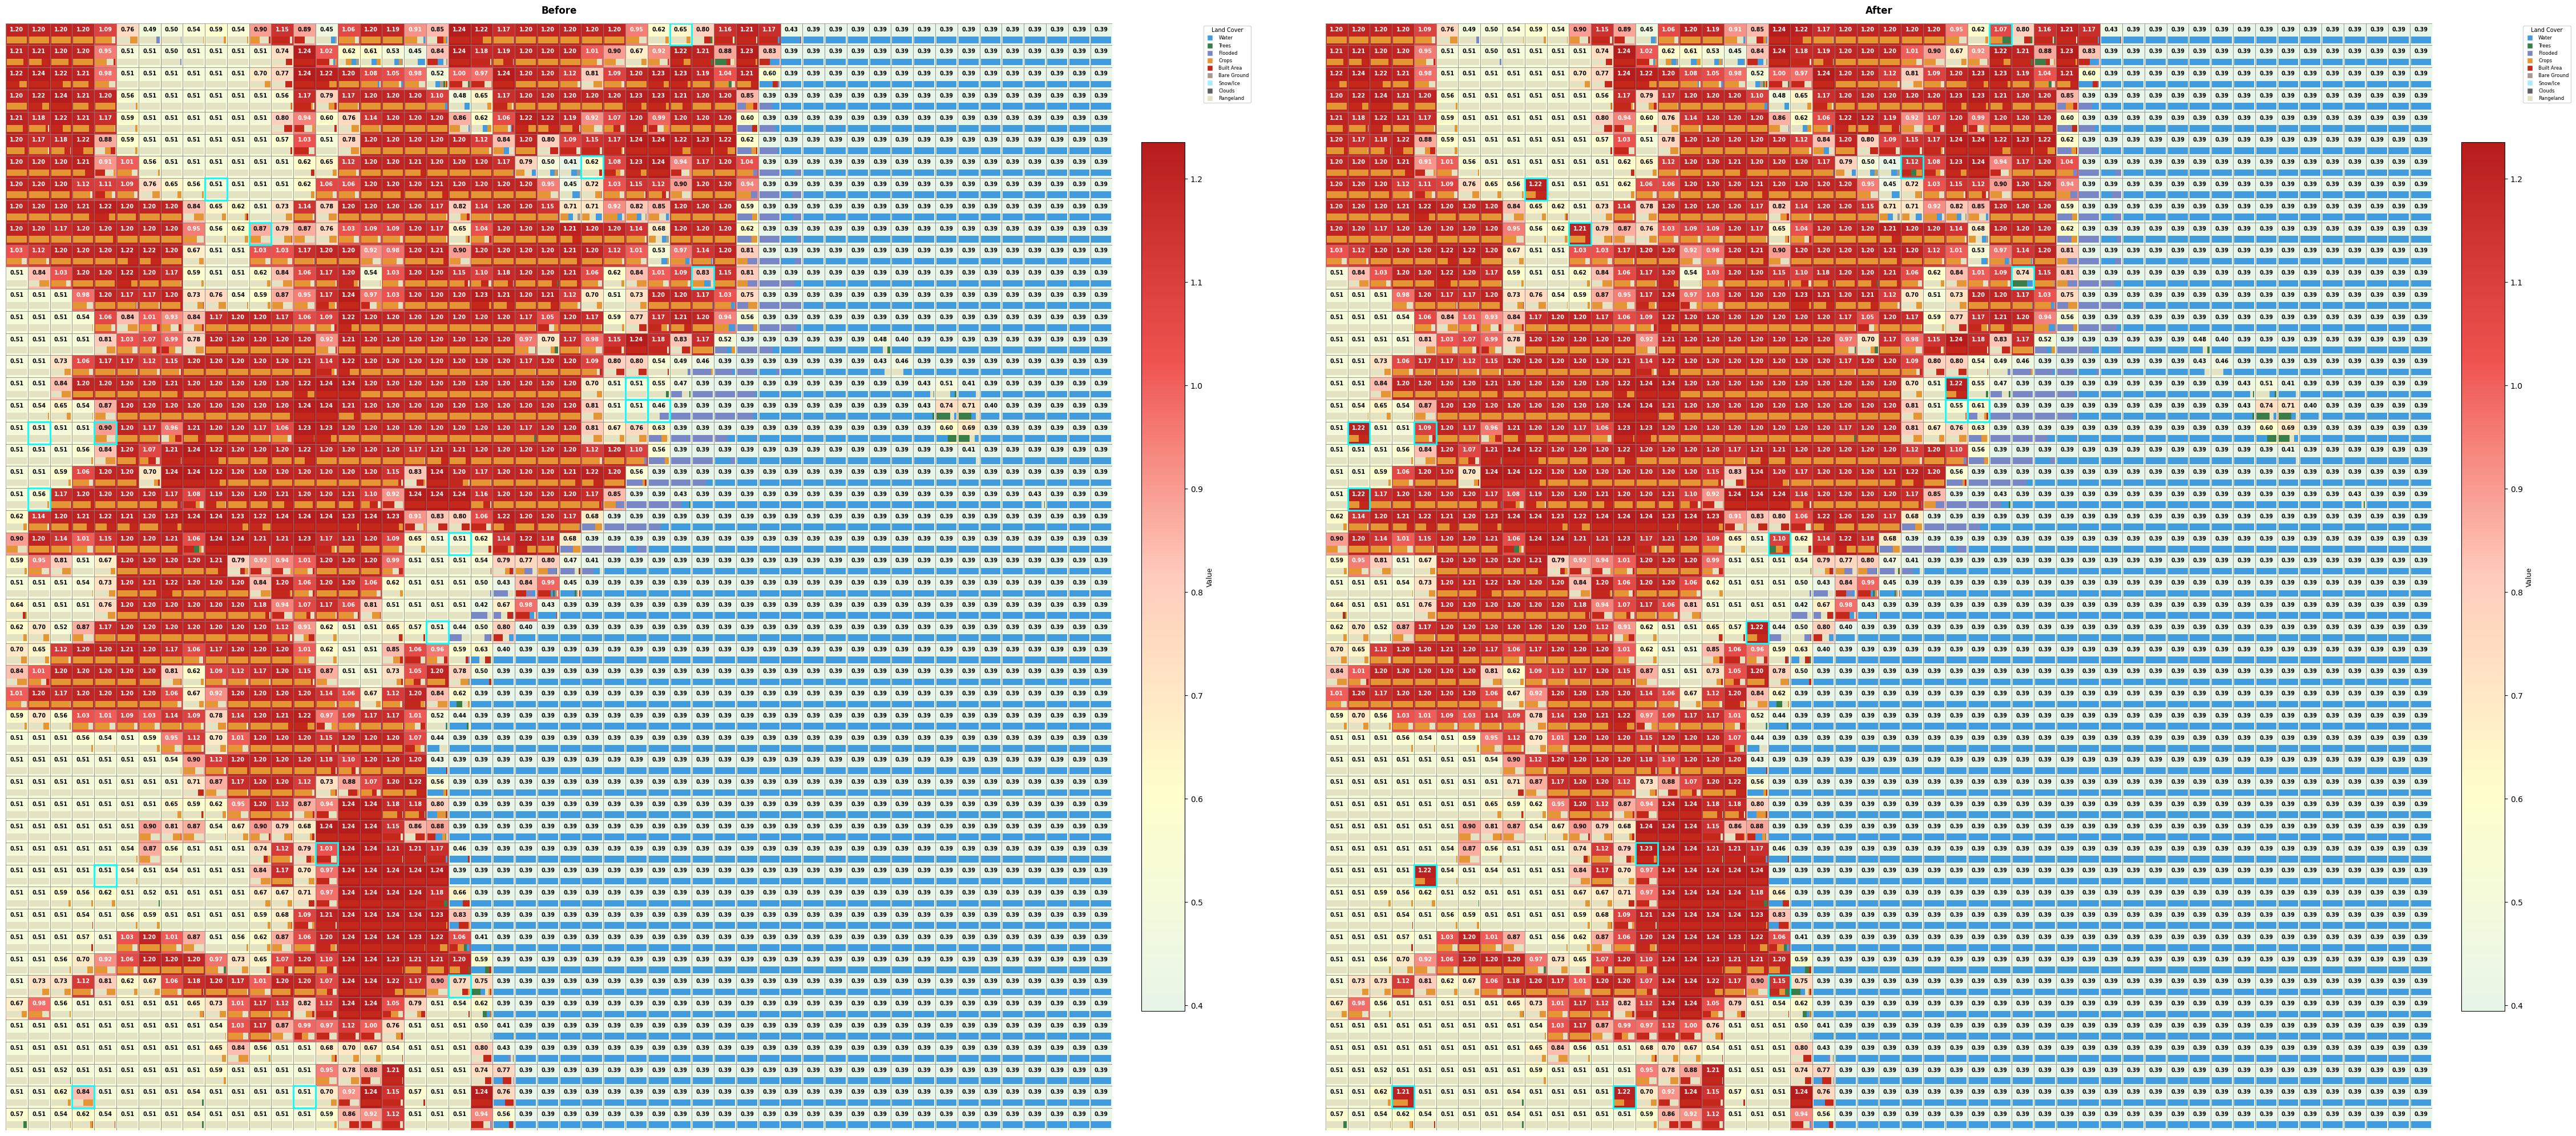

In [93]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from src.post_eda import plot_state_heatmap
plot_nm = "comparison_500000_total_500_steps_no_et_dcs_stop_filter_mod_only"

# value_per_class is your ECO_PER_CLASS + ET_PER_CLASS (shape N_CLASSES)
value_vec = ECO_PER_CLASS + ET_PER_CLASS

# Side-by-side comparison (both in fraction space)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(50, 20))
plot_state_heatmap(initial_obs, value_vec, title="Before", ax=ax1)
plot_state_heatmap(final_obs_recst, value_vec, title="After", ax=ax2)

# Highlight individual cells that changed (unique row, col from diffs)
n_rows = initial_obs.shape[0]
changed_cells = set((r, c) for r, c, *_ in diffs)
for (r, c) in changed_cells:
    for ax in (ax1, ax2):
        rect = patches.Rectangle(
            (c, n_rows - 1 - r), 1, 1,
            linewidth=2, edgecolor='cyan', facecolor='none'
        )
        ax.add_patch(rect)

plt.savefig(f"{plot_nm}.png", dpi=200, bbox_inches="tight")

In [ ]:
value_vec.shape

(12,)

In [29]:
info

{'total_value': 38.029200296664236, 'et_increase': 0.0, 'step': 0}

## Actor-Critic Netowrk

In [14]:
from stable_baselines3 import A2C

a2c_config = {
    "policy_type": "MlpPolicy",
    "features_extractor": "GridCNN",
    "features_out": 128,
    "env_name": "LakeMalawiLandUse-v0",
    "algorithm": "A2C",
    "total_timesteps": 500_000,
    "n_steps": 2048,
    "learning_rate": 3e-4,
    "gamma": 0.99,
    "gae_lambda": 0.95,
    "ent_coef": 0.02,
    "vf_coef": 0.5,
    "max_grad_norm": 0.5,
    "max_steps": 500,
    "lambda_cont": 0.5,
    "lambda_buf": 0.5,
    "lambda_et": 1.0,
    "reward_scale": 10.0,
}

a2c_policy_kwargs = dict(
    features_extractor_class=GridCNN,
    features_extractor_kwargs=dict(features_out=a2c_config["features_out"]),
)

# initialize WandB
a2c_run = wandb.init(
    project="CS8903-odc",
    config=a2c_config,
    sync_tensorboard=True,
    save_code=True,
)

logger.info("Creating A2C environment …")
a2c_env = LandUseEnv(
    split="train_indices",
    max_steps=a2c_config["max_steps"],
    lambda_cont=a2c_config["lambda_cont"],
    lambda_buf=a2c_config["lambda_buf"],
    lambda_et=a2c_config["lambda_et"],
    reward_scale=a2c_config["reward_scale"],
)

a2c_model = A2C(
    a2c_config["policy_type"],
    a2c_env,
    verbose=1,
    policy_kwargs=a2c_policy_kwargs,
    learning_rate=a2c_config["learning_rate"],
    n_steps=a2c_config["n_steps"],
    gamma=a2c_config["gamma"],
    gae_lambda=a2c_config["gae_lambda"],
    ent_coef=a2c_config["ent_coef"],
    vf_coef=a2c_config["vf_coef"],
    max_grad_norm=a2c_config["max_grad_norm"],
    tensorboard_log=f"runs/{a2c_run.id}",
)

print(a2c_model.policy)

# train
a2c_callbacks = [
    SpatialMetricsCallback(),
    WandbCallback(
        gradient_save_freq=100,
        model_save_path=f"models/{a2c_run.id}",
        verbose=2,
    ),
]

a2c_model.learn(total_timesteps=a2c_config["total_timesteps"], callback=a2c_callbacks, log_interval=1)
a2c_run.finish()


00:13:21 | __main__ | INFO    | Creating A2C environment …


wandb: WARNING When using several event log directories, please call `wandb.tensorboard.patch(root_logdir="...")` before `wandb.init`


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
ActorCriticPolicy(
  (features_extractor): GridCNN(
    (cnn): Sequential(
      (0): Conv2d(12, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Flatten(start_dim=1, end_dim=-1)
    )
    (linear): Sequential(
      (0): Linear(in_features=1600, out_features=128, bias=True)
      (1): ReLU()
    )
  )
  (pi_features_extractor): GridCNN(
    (cnn): Sequential(
      (0): Conv2d(12, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Flatten(start_dim=1, end_dim=-1)
    )
    (linear): Sequential(
      (0): Linear(in_features=1600, out_features=128, bias=True)
      (1): ReLU()
    )
  )
  (vf_features_extractor): GridCNN(
    (cnn): Sequent

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


global_step,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇█████
rollout/ep_len_mean,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
rollout/ep_rew_mean,▁▂▂▂▆▅▅▆▆▃▂▂▂▂▄▇▇▇▆▇▆▅▅▇▅▃▂▅▇█▅▅▆▅▅▆▅▄▄▄
spatial/buffer_penalty_mean,▅▅▄▂█▄▄▂▄▆▄▂▄▄▃▄▃▃▄▁▄▃▅▂▂▃▂▇▄▂▃▃▃▆▆▅▃▃▃▆
spatial/contiguity_bonus_mean,█▂▂▁▁█▆▂▁▇▂▁▆▁▇▇█▃██▇▁▁▆█▇▁▂█▂▁▁▇▁▂▇▂▁▁▁
time/fps,▁█▇▆▆▅▂▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▆▆▅▅▄▄▄▄▄▄▄▃
train/entropy_loss,▁▄▅▄▄▅▆▅▅▆▆▆▆▆▆▄▅▇▇█▆▆▆▆▆▇▆▇▇▅▅▆▆▆▆▅▇▇█▇
train/explained_variance,█▆█▆▁▇▇▅▇▇██▇▁▇██▆▇▇█▅▇█▅█▇▇▄██▇▇▇█▇▇▇█▇
train/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/policy_loss,▁▅▆▄▄▆▄▅█▄▄▅▆▃▅▇▃▇▄▃▅▅▅▄▂▁▇▃▃▇▄▆▅▅▅▅▆▄▆▅
+1,...


## Next Steps
1. Enhance background of project and domain interpretation in web page
2. ~~Refine training - constrain for protected class etc.~~
3. TODO: ~~why loss is negative?~~ what does epochs/max_steps/n_steps mean? ~~how SmallGridCNN integrate with MLP?~~
4. Test all samples
5. Understand how exactly model performs, what the evaluation metrics mean
...
6. Visualize learned policies on real geographical data

## Visualize State

## Playaround

In [70]:
data = np.load(Path(data_dir, "processed", "rl_dataset.npz"))
indices = data['train_indices']
indices

array([[10, 30],
       [30, 10],
       [ 0,  0],
       [40, 30],
       [20, 10],
       [10, 40],
       [20, 30],
       [ 0, 10],
       [40, 20],
       [10,  0],
       [ 0, 20],
       [20, 20],
       [30,  0],
       [ 0, 30],
       [ 0, 40],
       [40,  0],
       [30, 20]])

In [71]:
data['pixel_counts'][10:20, 30:40]

array([[[ 0,  5,  0, ...,  0,  0,  1],
        [ 0,  1,  0, ...,  0,  0,  1],
        [ 0,  0,  0, ...,  0,  0,  0],
        ...,
        [ 0, 25,  0, ...,  0,  0,  0],
        [ 0, 25,  0, ...,  0,  0,  0],
        [ 0, 25,  0, ...,  0,  0,  0]],

       [[ 0,  0,  0, ...,  0,  0,  4],
        [ 0,  7,  0, ...,  0,  0,  2],
        [ 0,  0,  0, ...,  0,  0,  0],
        ...,
        [ 0, 25,  0, ...,  0,  0,  0],
        [ 0, 25,  0, ...,  0,  0,  0],
        [ 0, 25,  0, ...,  0,  0,  0]],

       [[ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  1,  0, ...,  0,  0,  0],
        [ 0,  4,  0, ...,  0,  0,  0],
        ...,
        [ 0, 25,  0, ...,  0,  0,  0],
        [ 0, 25,  0, ...,  0,  0,  0],
        [ 0, 25,  0, ...,  0,  0,  0]],

       ...,

       [[ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        ...,
        [ 0, 25,  0, ...,  0,  0,  0],
        [ 0, 25,  0, ...,  0,  0,  0],
        [ 0, 25,  0, ...,  0,  0

In [12]:
grid_height = 10
grid_width = 10
num_features = 12
min_value = 0.0
max_value = 25.0

# 2. Define the Box space
# We pass scalar values for low and high, and Gymnasium will automatically 
# expand them to fit the provided shape.
grid_observation_space = Box(
    low=min_value, 
    high=max_value, 
    shape=(grid_height, grid_width, num_features), 
    dtype=np.int32
)
state_sample = grid_observation_space.sample()
print(state_sample)
print(state_sample.shape)
# net_values = state_sample * (ECO_PER_CLASS + ET_PER_CLASS)
# net_values
# float(net_values.sum())

[[[ 6 24 18 ...  8  9  4]
  [22  2 22 ... 15  3 13]
  [24 22  6 ...  9 19 16]
  ...
  [16 23 12 ... 13 17 10]
  [18 10 22 ...  9 22  8]
  [ 4 16  5 ... 10  1  9]]

 [[ 3 20  4 ...  3 21 14]
  [25 25 24 ... 23 18  1]
  [17 23  2 ...  5 12 12]
  ...
  [14  4  4 ... 21 14 20]
  [ 9 25  1 ... 18 11  8]
  [14 21 21 ... 10 14 24]]

 [[15  2 25 ...  0 23 21]
  [ 5 14 21 ... 23 10  4]
  [ 7 12  6 ... 25  2  4]
  ...
  [ 3  5 13 ... 12  7  3]
  [ 7 10 23 ... 23  9 23]
  [ 4  2  0 ...  8 10  2]]

 ...

 [[10 22 24 ...  5 22  6]
  [23 10 10 ... 13 24  6]
  [13 21 21 ... 20  9 22]
  ...
  [22  9 25 ...  5 10 21]
  [20  6 22 ... 21 10  8]
  [21 22 19 ... 18 12  6]]

 [[16 24 11 ... 18 17  1]
  [24 12 25 ...  4  3  5]
  [ 4  9  0 ...  7 23 13]
  ...
  [18  9 25 ... 17  0 21]
  [15  9 24 ...  4 15  1]
  [ 7 17 16 ... 18 13  8]]

 [[13 25 10 ... 24 13  2]
  [21  2 20 ... 15 13  2]
  [15 21  8 ... 25  0 13]
  ...
  [ 6  5 23 ... 24 24 18]
  [ 9 24  0 ... 18 18  8]
  [19 16 16 ... 25  1  4]]]
(10, 10, 1

In [47]:
grid_observation_space.shape

(10, 10, 12)

In [46]:
print(state_sample[6, 4, :])
print(state_sample[6, 4, :] + action_sample['delta_s'])

[ 2 25  4  5  5 25 24 24 20 11 25 11]
[ 11  14 -19  16 -15  30  28  37  11 -14  46  -9]


In [52]:
action_space = Dict({
    # select the (i, j) cell
    "cell_coords": MultiDiscrete([size, size]), 
    # delta change for the 12 land-use types
    "delta_s": Box(low=-1, high=1, shape=(N_CLASSES,), dtype=int)
})
action_sample = action_space.sample()
action_sample

{'cell_coords': array([4, 4]),
 'delta_s': array([-1,  1,  0,  0, -1,  1,  1,  1,  1,  0,  1, -1])}

In [45]:
cell_coords = action_sample['cell_coords']
state_sample[cell_coords[0], cell_coords[1], :]

array([ 2, 25,  4,  5,  5, 25, 24, 24, 20, 11, 25, 11])